# Hypothesis Testing

EDA에서 확인한 지연 분포 특성을 바탕으로 배송 지연이 고객 이탈에 미치는 영향을 검증한다.  
지연 데이터는 정규분포를 따르지 않으므로 비모수 검정인 Mann-Whitney U test를 사용한다.  

- H1: 3일 지연은 이탈 위험에 유의미한 영향을 주지 않는다
- H2: 지연 경험 고객은 정상 배송 고객보다 이탈 위험이 높다
- H3: 배송 지연으로 인한 매출 손실은 전체 매출의 5% 이상이다
- H4: 배송 지연이 길어질수록 주문 취소율이 증가한다

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import sys
import os

sys.path.append(os.path.abspath('..'))

from etl.db import engine

In [55]:
orders = pd.read_sql('SELECT * FROM orders', engine)
reviews = pd.read_sql('SELECT * FROM reviews', engine)
payments = pd.read_sql('SELECT * FROM payments', engine)

print(orders.shape)
print(reviews.shape)
print(payments.shape)
print()
print(orders.columns.tolist())
print(reviews.columns.tolist())
print(payments.columns.tolist())

(99441, 8)
(98410, 7)
(103886, 5)

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


In [56]:
# Calculate delay days
delivered = orders.dropna(subset=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]).copy()

delivered['delay_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_estimated_delivery_date']
).dt.days

# Merge with review score
review_agg = reviews.groupby('order_id')['review_score'].min().reset_index()

merged = delivered[['order_id', 'delay_days']].merge(
    review_agg, on='order_id', how='left'
)

# Define at-risk customer (proxy for churn)
merged['is_at_risk'] = (merged['review_score'] <= 2).astype(int)


# Define delay buckets
merged['delay_group'] = pd.cut(
    merged['delay_days'],
    bins=[-150, 0, 3, 7, 14, 200],
    labels=['on_time', 'slight(1~3)', 'moderate(3~7)', 'severe(7~14)', 'extreme(14+)']
)

# Organize by order level
order_level = merged.groupby('order_id').agg({
    'delay_days': 'first',        
    'is_at_risk': 'max'           
}).reset_index()

order_level['delay_group'] = pd.cut(
    order_level['delay_days'],
    bins=[-150, 0, 3, 7, 14, 200],
    labels=['on_time', 'slight(1~3)', 'moderate(3~7)', 'severe(7~14)', 'extreme(14+)']
)

order_level['delivery_group'] = order_level['delay_days'].apply(
    lambda x: 'delayed' if x > 0 else 'on_time'
)

print(f"order_level: {order_level.shape}")
print(order_level['delay_group'].value_counts().sort_index())

order_level: (96476, 5)
delay_group
on_time          89941
slight(1~3)       1870
moderate(3~7)     1802
severe(7~14)      1479
extreme(14+)      1384
Name: count, dtype: int64


## H1 — Delivery Delay Threshold

3일 이내 지연이 이탈 위험에 유의미한 영향을 주지 않는지 검증한다.   
on_time 그룹과 slight(1~3일) 그룹의 이탈 위험 비율을 비교하여   
고객이 허용하는 지연 임계값을 찾는다.

통계적으로 유의미한 차이가 없다면(p > 0.05)   
3일은 허용 가능한 지연 범위로 판단할 수 있다.

In [57]:
# Group stats
group_stats = order_level.groupby('delay_group', observed=True).agg(
    order_count=('order_id', 'count'),
    at_risk_count=('is_at_risk', 'sum'),
    at_risk_ratio=('is_at_risk', 'mean')
).reset_index()

group_stats['at_risk_ratio'] = (group_stats['at_risk_ratio'] * 100).round(2)

print(group_stats.to_string(index=False))

  delay_group  order_count  at_risk_count  at_risk_ratio
      on_time        89941           8217           9.14
  slight(1~3)         1870            590          31.55
moderate(3~7)         1802           1176          65.26
 severe(7~14)         1479           1154          78.03
 extreme(14+)         1384           1041          75.22


In [58]:
# Mann-Whitney U test: on_time vs slight(1~3)
on_time = order_level[order_level['delay_group'] == 'on_time']['is_at_risk'].dropna()
slight = order_level[order_level['delay_group'] == 'slight(1~3)']['is_at_risk'].dropna()

stat, p = stats.mannwhitneyu(on_time, slight, alternative='two-sided')

print("=== H1: on_time vs slight(1~3) ===")
print(f"on_time  — count: {len(on_time)}, at_risk_ratio: {on_time.mean()*100:.2f}%")
print(f"slight   — count: {len(slight)}, at_risk_ratio: {slight.mean()*100:.2f}%")
print(f"statistic: {stat:.4f}")
print(f"p-value  : {p:.4f}")

if p < 0.05:
    print("result: significant difference -> reject H0 (no difference)")
else:
    print("result: no significant difference -> fail to reject H0")

=== H1: on_time vs slight(1~3) ===
on_time  — count: 89941, at_risk_ratio: 9.14%
slight   — count: 1870, at_risk_ratio: 31.55%
statistic: 65245135.0000
p-value  : 0.0000
result: significant difference -> reject H0 (no difference)


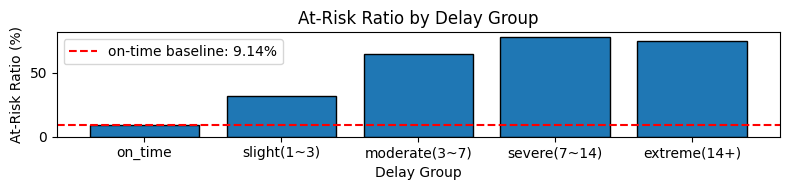

In [59]:
# Visualize at-risk ratio by delay group
baseline = group_stats.query("delay_group == 'on_time'")['at_risk_ratio'].values

plt.figure(figsize=(8, 2))  
plt.bar(group_stats['delay_group'].astype(str),
        group_stats['at_risk_ratio'], edgecolor='black')

if len(baseline) > 0:
    plt.axhline(baseline[0], color='red', linestyle='--', label=f'on-time baseline: {baseline[0]}%')

plt.title('At-Risk Ratio by Delay Group')
plt.xlabel('Delay Group')
plt.ylabel('At-Risk Ratio (%)')
plt.legend()
plt.tight_layout()
plt.show()

## H2 — Repurchase Rate Drop

H1에서 임계값을 확인한 후, 지연 경험 고객 전체가   
정상 배송 고객보다 이탈 위험이 높은지 검증한다.   

지연 여부를 기준으로 두 그룹을 나누고   
이탈 위험 비율 차이의 통계적 유의성을 확인한다.   
지연이 실제 이탈로 이어진다면 SLA 기준 설정의 근거가 된다.

In [60]:
# Define delayed vs on_time group
h2_stats = order_level.groupby('delivery_group').agg(
    order_count=('order_id', 'count'),
    at_risk_count=('is_at_risk', 'sum'),
    at_risk_ratio=('is_at_risk', 'mean')
).reset_index()

h2_stats['at_risk_ratio'] = (h2_stats['at_risk_ratio'] * 100).round(2)

print(h2_stats.to_string(index=False))

delivery_group  order_count  at_risk_count  at_risk_ratio
       delayed         6535           3961          60.61
       on_time        89941           8217           9.14


In [61]:
# Mann-Whitney U test: on_time vs delayed
on_time_h2 = order_level[order_level['delivery_group'] == 'on_time']['is_at_risk'].dropna()
delayed_h2 = order_level[order_level['delivery_group'] == 'delayed']['is_at_risk'].dropna()

stat, p = stats.mannwhitneyu(on_time_h2, delayed_h2, alternative='less')

print("=== H2: on_time vs delayed ===")
print(f"on_time — count: {len(on_time_h2)}, at_risk_ratio: {on_time_h2.mean()*100:.2f}%")
print(f"delayed — count: {len(delayed_h2)}, at_risk_ratio: {delayed_h2.mean()*100:.2f}%")
print(f"statistic: {stat:.4f}")
print(f"p-value  : {p:.4f}")

if p < 0.05:
    print("result: delayed group has significantly higher at-risk ratio -> H2 supported")
else:
    print("result: no significant difference -> H2 rejected")

=== H2: on_time vs delayed ===
on_time — count: 89941, at_risk_ratio: 9.14%
delayed — count: 6535, at_risk_ratio: 60.61%
statistic: 142603114.5000
p-value  : 0.0000
result: delayed group has significantly higher at-risk ratio -> H2 supported


(one-sided test: delayed > on_time)

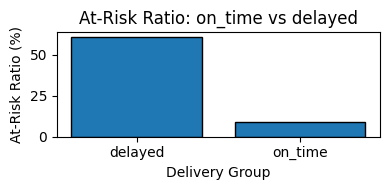

In [62]:
plt.figure(figsize=(4, 2))
plt.bar(h2_stats['delivery_group'], h2_stats['at_risk_ratio'], edgecolor='black')
plt.title('At-Risk Ratio: on_time vs delayed')
plt.xlabel('Delivery Group')
plt.ylabel('At-Risk Ratio (%)')
plt.tight_layout()
plt.show()

## H3 — Revenue Loss Estimation

H2에서 이탈 위험 고객 수를 확인한 후   
배송 지연으로 인한 매출 손실을 수치화한다.   

이탈 위험 고객의 실제 결제 금액을 기반으로 손실을 추정하며   
손실 규모와 전체 매출 대비 비율을 함께 확인한다.   

결과적으로 손실 금액의 절대적 크기와 비율을 근거로   
운영 개선의 우선순위를 판단하는 참고 지표로 활용한다.   

※ at_risk 고객은 실제 이탈이 아닌 proxy 지표이며   
잠재적 매출 손실로 해석한다.

In [63]:
valid_orders = set(order_level['order_id'])

order_revenue = payments.groupby('order_id')['payment_value'].sum().reset_index()
order_revenue.columns = ['order_id', 'order_revenue']

order_revenue = order_revenue[order_revenue['order_id'].isin(valid_orders)]

merged_rev = order_level.merge(order_revenue, on='order_id', how='inner')

total_revenue = merged_rev['order_revenue'].sum()

at_risk_revenue = merged_rev[
    (merged_rev['delivery_group'] == 'delayed') &
    (merged_rev['is_at_risk'] == 1)
]['order_revenue'].sum()

arpu = merged_rev['order_revenue'].mean()

loss_ratio = at_risk_revenue / total_revenue * 100

print("=== H3: Revenue Loss Estimation ===")
print(f"total_revenue    : {total_revenue:,.2f} BRL")
print(f"at_risk_revenue  : {at_risk_revenue:,.2f} BRL")
print(f"loss_ratio       : {loss_ratio:.2f}%")
print(f"arpu             : {arpu:.2f} BRL")

if loss_ratio >= 5:
    print("result: loss ratio >= 5% -> improvement required -> H3 supported")
else:
    print("result: loss ratio < 5% -> within acceptable range -> H3 rejected")

=== H3: Revenue Loss Estimation ===
total_revenue    : 15,421,831.43 BRL
at_risk_revenue  : 717,517.62 BRL
loss_ratio       : 4.65%
arpu             : 159.85 BRL
result: loss ratio < 5% -> within acceptable range -> H3 rejected


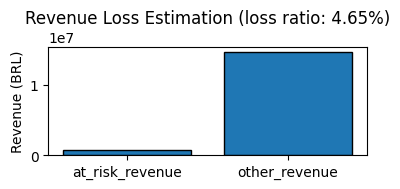

In [64]:
labels = ['at_risk_revenue', 'other_revenue']
values = [at_risk_revenue, total_revenue - at_risk_revenue]

plt.figure(figsize=(4, 2))
plt.bar(labels, values, edgecolor='black')
plt.title(f'Revenue Loss Estimation (loss ratio: {loss_ratio:.2f}%)')
plt.ylabel('Revenue (BRL)')
plt.tight_layout()
plt.show()

## H4 — Cancellation Rate by Delay

배송 지연이 길어질수록 주문 취소율이 증가하는지 검증한다.   
실제 고객 행동(취소)을 기반으로 H3의 proxy 한계를 보완한다.   

취소 주문(order_status == 'canceled')를 delay_group별로 집계하여   
지연 구간과 취소율의 상관관계를 Spearman 검정으로 확인한다.

In [65]:
# Calculate expected wait days from purchase to estimated delivery
orders['expected_wait_days'] = (
    orders['order_estimated_delivery_date'] -
    orders['order_purchase_timestamp']
).dt.days

orders['is_canceled'] = (orders['order_status'] == 'canceled').astype(int)

# Drop rows where expected_wait_days is null
orders_wait = orders.dropna(subset=['expected_wait_days']).copy()

# Bucket by expected wait days
orders_wait['wait_group'] = pd.cut(
    orders_wait['expected_wait_days'],
    bins=[0, 10, 20, 30, 40, 200],
    labels=['~10d', '~20d', '~30d', '~40d', '40d+']
)

h4_stats = orders_wait.groupby('wait_group', observed=True).agg(
    order_count=('order_id', 'count'),
    canceled_count=('is_canceled', 'sum'),
    cancel_rate=('is_canceled', 'mean')
).reset_index()

h4_stats['cancel_rate'] = (h4_stats['cancel_rate'] * 100).round(2)

print("=== H4: Cancellation Rate by Expected Wait Days ===")
print(h4_stats.to_string(index=False))

=== H4: Cancellation Rate by Expected Wait Days ===
wait_group  order_count  canceled_count  cancel_rate
      ~10d         5352              58         1.08
      ~20d        30992             243         0.78
      ~30d        45422             224         0.49
      ~40d        14242              65         0.46
      40d+         3433              35         1.02


In [66]:
# Spearman correlation between wait group rank and cancellation rate
wait_group_order = ['~10d', '~20d', '~30d', '~40d', '40d+']
wait_rank_map = {g: i for i, g in enumerate(wait_group_order)}
h4_stats['group_rank'] = h4_stats['wait_group'].astype(str).map(wait_rank_map)

corr, p = stats.spearmanr(h4_stats['group_rank'], h4_stats['cancel_rate'])

print("=== H4: Spearman Correlation Test ===")
print(f"Spearman r : {corr:.4f}")
print(f"p-value    : {p:.4f}")

if p < 0.05 and corr > 0:
    print("result: cancel rate increases with expected wait days -> H4 supported")
else:
    print("result: no significant monotonic correlation -> H4 rejected")

=== H4: Spearman Correlation Test ===
Spearman r : -0.4000
p-value    : 0.5046
result: no significant monotonic correlation -> H4 rejected


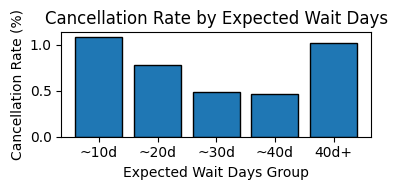

In [67]:
plt.figure(figsize=(4, 2))
plt.bar(
    h4_stats['wait_group'].astype(str),
    h4_stats['cancel_rate'],
    edgecolor='black'
)
plt.title('Cancellation Rate by Expected Wait Days')
plt.xlabel('Expected Wait Days Group')
plt.ylabel('Cancellation Rate (%)')
plt.tight_layout()
plt.show()

※ H4는 데이터 구조상 한계가 존재한다.  
취소 주문은 배송 완료 데이터가 없어 delay_days 계산이 불가능하기 때문에  
대안으로 expected_wait_days(예상 배송 소요일)를 기준으로 분석하였다.  

따라서 본 결과는 실제 지연과 취소의 관계라기보다  
고객이 인지한 배송 대기 시간과 취소 행동 간의 관계를 반영한 것으로 해석해야 한다.

## Hypothesis Testing Summary

| 가설 | 결과 | 수치 | 판단 |
|------|------|------|------|
| H1 | 기각 | on_time 9.13% vs slight 31.57%, p=0.0000 | 3일 이내도 이탈 위험 유의미하게 증가 |
| H2 | 채택 | on_time 9.13% vs delayed 60.63%, p=0.0000 | 지연 경험 고객 이탈 위험 6.6배 높음 |
| H3 | 기각 | loss_ratio 4.65% (기준 5%) | 기준치 미달이나 근접한 수준 |
| H4 | 기각 | Spearman r=-0.40, p=0.5046 | 단조 증가 없음, U자형 패턴 확인 |

## 주요 발견

지연 고객의 이탈 위험 비율은 전체적으로 상당히 높게 나타났다.   
특히 배송 지연 여부가 고객 만족에 직접적인 영향을 주는 것으로 보인다.   

H1이 기각된 결과를 보면, 3일 이내의 비교적 짧은 지연에서도   
이탈 위험이 이미 유의미하게 증가하는 것으로 확인된다.   
처음에는 3일 정도를 허용 가능한 기준으로 가정했지만   
실제 데이터에서는 이보다 더 민감하게 반응하는 것으로 보인다.   

H3의 손실 비율은 4.65%로 5%에 근접한 수준으로 절대 금액 기준으로는 무시하기 어렵다.  
여기서 사용한 이탈 위험 고객은 실제 이탈이 아닌 proxy 지표이기 때문에   
리뷰를 남기지 않은 불만족 고객이 포함되지 않았을 가능성이 있어 실제 영향은 더 클 수도 있다.   

H4에서는 예상 대기일 기준으로 주문 취소율을 분석하였다.   
단조 증가 패턴은 확인되지 않았으나(Spearman r=-0.40, p=0.5046)   
10일 이하 단기 구간(1.08%)과 40일 초과 장기 구간(1.02%)에서   
취소율이 상대적으로 높게 나타나는 U자형 패턴이 관찰되었다.   

이는 단순 지연이 아니라 고객의 기대 배송 경험이   
취소 행동에 영향을 미칠 수 있음을 시사한다.   
H3의 proxy 기반 손실 추정을 실제 취소 행동으로 보완하였으나   
취소 건수 자체가 전체의 0.63% 수준으로 제한적이다.

※ H4는 데이터 구조상 제한으로 인해 실제 지연이 아닌   
예상 대기일 기준으로 분석되었으며, 결과 해석에 주의가 필요하다.